# Regularization: Ridge, Lasso & Elastic Net
### Easy self-study notes + quick revision + runnable Python

**Goal:** Understand *why* regularization is used, what **Ridge / Lasso / Elastic Net** do, and how `alpha (λ)` changes a regression model.

### 60-second map
- **Overfitting** → model learns training data too closely and performs worse on new data.
- **Regularization** → adds a penalty for large coefficients/weights.
- **Ridge (L2)** → shrinks coefficients.
- **Lasso (L1)** → shrinks coefficients and can make some exactly `0`.
- **Elastic Net** → combines Ridge + Lasso.
- **Bigger alpha (λ)** → stronger regularization.
- **Too much regularization** → underfitting.
- **Choose alpha** → use cross-validation, then check once on the test set.

## 1. Tiny recap: Linear Regression

For one feature:


$$
\hat y = \theta_0 + \theta_1x
$$


For many features:


$$
\hat y = \theta_0 + \theta_1x_1 + \theta_2x_2 + \cdots
$$


- `ŷ` = prediction
- `θ₀` = intercept
- `θ₁, θ₂, ...` = coefficients / weights / slopes
- `x₁, x₂, ...` = input features

**Simple meaning:** a coefficient tells how strongly a feature changes the prediction, while the other features are held fixed.

### Cost function, MSE, and global minimum

The model needs a way to measure **how wrong** its predictions are.

A common regression cost is **Mean Squared Error (MSE)**:


$$
MSE = \frac{1}{m}\sum_{i=1}^{m}(\hat y_i-y_i)^2
$$


The model wants the cost to be as small as possible.

**Gradient descent idea:** keep changing the coefficients in the direction that lowers the cost.  
The lowest point is called the **global minimum**.

For ordinary linear regression with squared error, the cost surface is convex, so there is one global minimum.

## 2. The problem: Overfitting

Imagine a student **memorizes practice questions** instead of learning the concept.

A model can do the same:

- **Training error:** very small
- **Validation/test error:** much larger
- Typical description: **low bias + high variance**

That is **overfitting**.

> Important: a perfect training score can be a warning sign, but it is **not proof** of overfitting. We confirm overfitting by checking performance on unseen data.

## 3. Regularization: the big idea

Ordinary regression tries to minimize prediction error.

Regularized regression tries to minimize:


$$
\text{prediction error} + \text{penalty for large coefficients}
$$


Why? Very large coefficients can make a model react too strongly to small changes in the data.

The penalty strength is controlled by **lambda (λ)**.  
In scikit-learn, it is usually called **`alpha`**.

- `alpha = 0` → no regularization
- small `alpha` → light penalty
- large `alpha` → strong penalty

Think of `alpha` as a **strictness knob**.

## 4. Ridge Regression = L2 Regularization

Ridge adds the **squares of the coefficients** to the cost:


$$
J = MSE + \lambda\sum_{j=1}^{p}\theta_j^2
$$


The intercept is normally **not** penalized.

### What Ridge does
If a coefficient was:

`0.52 → 0.40 → 0.22 → ...`

Ridge keeps pulling it toward zero as regularization increases.

**Key idea:** Ridge usually keeps every feature, but reduces how strongly features can affect the prediction.

### Easy memory
**Ridge = SHRINK**

### Relationship between λ and the coefficients

When `λ = 0`, Ridge becomes ordinary linear regression.

As `λ` increases:


$$
\lambda \uparrow \quad \Rightarrow \quad |\theta_j| \downarrow \text{ (generally)}
$$


So stronger Ridge regularization moves coefficient magnitudes closer to zero.

Ridge coefficients **typically do not become exactly zero**, so Ridge is not normally used for automatic feature selection.

## 5. Lasso Regression = L1 Regularization

Lasso adds the **absolute values** of coefficients:


$$
J = MSE + \lambda\sum_{j=1}^{p}|\theta_j|
$$


### What Lasso does
It shrinks coefficients like Ridge, **but some can become exactly `0`**.

Example:

| Feature | Before | After Lasso |
|---|---:|---:|
| Study hours | 0.52 | 0.41 |
| Practice | 0.48 | 0.35 |
| Random feature | 0.10 | **0.00** |

A coefficient of `0` means that fitted Lasso model is not using that feature.

### Easy memory
**Lasso = SHRINK + SELECT**

## 6. Elastic Net = L1 + L2

Elastic Net combines the two ideas:

- **L1 part** → can make coefficients zero
- **L2 part** → smoothly shrinks coefficients

It is useful when you have **many features**, especially when some features carry similar information.

In scikit-learn:

- `alpha` = total regularization strength
- `l1_ratio = 0` → Ridge-like
- `l1_ratio = 1` → Lasso-like
- between `0` and `1` → mixture

### Easy memory
**Elastic Net = Ridge + Lasso**

## 7. Quick comparison

| Model | Penalty | Coefficients | Feature selection? |
|---|---|---|---|
| Linear Regression | None | Can stay large | No |
| **Ridge** | Squares (`L2`) | Shrink toward 0 | Usually no |
| **Lasso** | Absolute values (`L1`) | Shrink; some can become 0 | Yes |
| **Elastic Net** | `L1 + L2` | Shrink; some can become 0 | Yes |

### One-line revision
**Ridge shrinks. Lasso shrinks + selects. Elastic Net does both.**

## 8. Bias–variance trade-off

Regularization is a balancing act.

- **Too little regularization** → model may overfit → higher variance
- **Too much regularization** → model may become too simple → higher bias / underfitting
- **Good alpha** → useful balance on unseen data

So **bigger alpha is not always better**.

## 9. Why scaling matters

Suppose:

- age is around `20`
- salary is around `1,000,000`

Their units are very different. Since regularization penalizes coefficient sizes, features should usually be put on a similar scale first.

We will use:

```python
StandardScaler()
```

and keep it inside a **Pipeline** so scaling is learned only from training data.

# Hands-on Python

We will create a small **pretend student dataset**.  
The goal is learning the models—not making claims about real students.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

## 10. Create a simple dataset

Features:
- `study_hours`
- `practice_questions`
- `sleep_hours`
- `phone_hours`

Target:
- `score`

`practice_questions` is partly related to `study_hours`, which gives us two overlapping/correlated features—useful for seeing regularization.

In [2]:
rng = np.random.default_rng(7)
rows = 240

study_hours = rng.uniform(0, 8, rows)
practice_questions = 2 * study_hours + rng.normal(0, 3, rows)
sleep_hours = rng.uniform(4, 10, rows)
phone_hours = rng.uniform(0, 7, rows)

noise = rng.normal(0, 5, rows)

score = (
    50
    + 3.0 * study_hours
    + 1.2 * practice_questions
    + 1.5 * sleep_hours
    - 2.0 * phone_hours
    + noise
)

data = pd.DataFrame({
    "study_hours": study_hours,
    "practice_questions": practice_questions,
    "sleep_hours": sleep_hours,
    "phone_hours": phone_hours,
    "score": score,
})

data.head()

,study_hours,practice_questions,sleep_hours,phone_hours,score
0,5.000764,9.733064,6.229765,5.944086,74.473616
1,7.177710,14.313332,7.488566,6.371951,87.347344
2,6.205486,8.061380,9.687391,0.309916,89.373917
3,1.801658,2.222734,9.334437,2.326936,65.290312
4,2.401330,7.032252,6.262832,1.347462,77.908704


### Code meaning
- `default_rng(7)` → same random data every run
- `noise` → real-world style randomness
- `DataFrame` → puts values into a readable table
- `head()` → shows the first 5 rows

## 11. X, y, training set, test set

- `X` = input features / clues
- `y` = target / answer
- **training set** = model learns from it
- **test set** = kept hidden until final evaluation

Think: **practice questions vs final test**.

In [3]:
feature_names = [
    "study_hours",
    "practice_questions",
    "sleep_hours",
    "phone_hours",
]

X = data[feature_names]
y = data["score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=7,
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 180
Test rows: 60


## 12. Train Linear, Ridge, Lasso, and Elastic Net

A **Pipeline** means:

`data → StandardScaler → regression model`

Useful commands:
- `.fit()` → learn
- `.predict()` → make predictions

In [4]:
models = {
    "Linear": make_pipeline(
        StandardScaler(),
        LinearRegression()
    ),
    "Ridge": make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0)
    ),
    "Lasso": make_pipeline(
        StandardScaler(),
        Lasso(alpha=0.2, max_iter=20_000)
    ),
    "Elastic Net": make_pipeline(
        StandardScaler(),
        ElasticNet(alpha=0.2, l1_ratio=0.5, max_iter=20_000)
    ),
}

results = []
coefficient_rows = []

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    rmse = mean_squared_error(y_test, predictions) ** 0.5
    r2 = r2_score(y_test, predictions)

    results.append({
        "model": name,
        "test_RMSE": rmse,
        "test_R2": r2,
    })

    coefficient_rows.append(pipeline.steps[-1][1].coef_)

results_table = pd.DataFrame(results).round(3)
results_table

,model,test_RMSE,test_R2
0,Linear,5.363,0.888
1,Ridge,5.369,0.888
2,Lasso,5.430,0.885
3,Elastic Net,5.609,0.878


### How to read the metrics

**RMSE**
- roughly: size of prediction errors
- **smaller is better**
- same unit as the target (`score` here)

**R²**
- `1` → predictions fit extremely well
- `0` → about as useful as predicting the average
- `< 0` → worse than that simple average baseline

Do not decide the “best model” from one split alone. Use cross-validation.

## 13. Look at the learned coefficients

Because the inputs were standardized, their coefficient sizes are easier to compare.

- positive coefficient → pushes prediction upward
- negative coefficient → pushes prediction downward
- zero coefficient → model is not using that feature

In [5]:
coefficient_table = pd.DataFrame(
    coefficient_rows,
    index=models.keys(),
    columns=feature_names,
).round(3)

coefficient_table

,study_hours,practice_questions,sleep_hours,phone_hours
Linear,7.507,6.378,2.208,-4.125
Ridge,7.460,6.379,2.194,-4.095
Lasso,7.343,6.293,1.997,-3.880
Elastic Net,6.790,6.203,1.889,-3.531


### What to notice
- Ridge tends to make coefficients smaller.
- Lasso may push a weak coefficient to exactly `0`.
- Elastic Net can do both.
- A small coefficient does **not automatically mean** the original feature is useless; the result depends on the dataset, scaling, and alpha.

## 14. Watch coefficients change as alpha increases

Read each graph from **left → right**:

`small alpha → large alpha`

This makes the transcript's main Ridge idea visible: stronger regularization usually means smaller coefficient magnitudes.

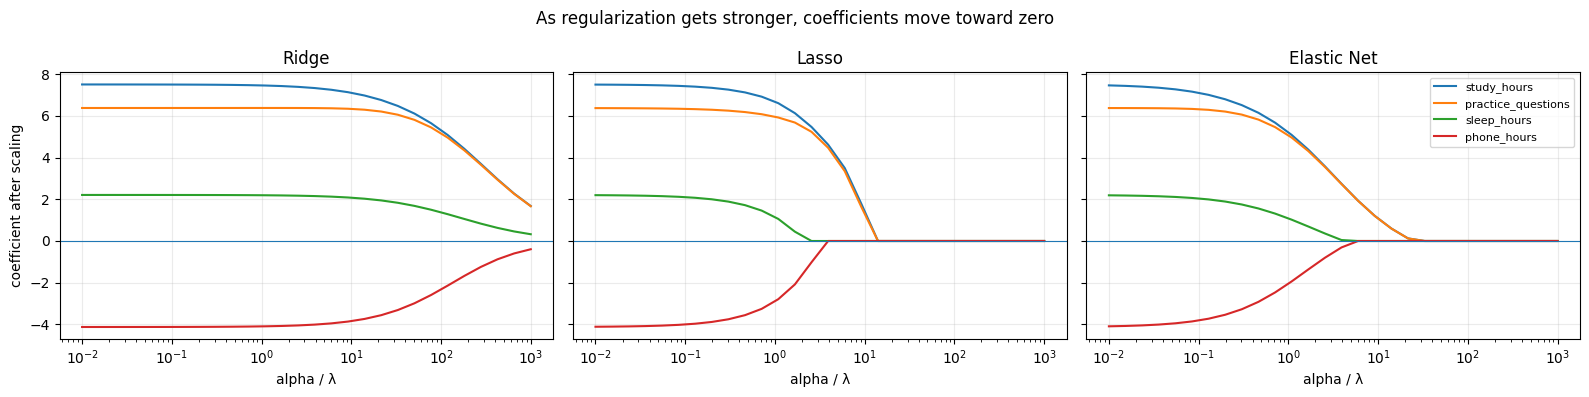

In [6]:
alphas = np.logspace(-2, 3, 28)
model_types = ["Ridge", "Lasso", "Elastic Net"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, name in zip(axes, model_types):
    coefficient_path = []

    for alpha in alphas:
        if name == "Ridge":
            model = Ridge(alpha=alpha)
        elif name == "Lasso":
            model = Lasso(alpha=alpha, max_iter=20_000)
        else:
            model = ElasticNet(
                alpha=alpha,
                l1_ratio=0.5,
                max_iter=20_000
            )

        pipeline = make_pipeline(StandardScaler(), model)
        pipeline.fit(X_train, y_train)
        coefficient_path.append(
            pipeline.steps[-1][1].coef_
        )

    coefficient_path = np.array(coefficient_path)

    for feature_index, feature in enumerate(feature_names):
        ax.plot(
            alphas,
            coefficient_path[:, feature_index],
            label=feature
        )

    ax.set_xscale("log")
    ax.set_title(name)
    ax.set_xlabel("alpha / λ")
    ax.axhline(0, linewidth=0.8)
    ax.grid(alpha=0.25)

axes[0].set_ylabel("coefficient after scaling")
axes[-1].legend(fontsize=8)
fig.suptitle("As regularization gets stronger, coefficients move toward zero")
fig.tight_layout()
plt.show()

### Diagram takeaway
- **Ridge:** smooth shrinkage toward zero
- **Lasso:** some lines can hit exactly zero
- **Elastic Net:** mixture of both behaviors

The exact paths depend on the data.

## 15. How do we choose alpha? Cross-validation

Do **not** pick alpha just because it looks nice.

Cross-validation repeatedly:
1. trains on part of the training data,
2. checks on another part,
3. compares different alpha values.

Then we choose the value that works well across those checks.

The untouched **test set** is used only after model selection.

In [7]:
ridge_search = GridSearchCV(
    estimator=make_pipeline(StandardScaler(), Ridge()),
    param_grid={"ridge__alpha": np.logspace(-3, 3, 13)},
    scoring="neg_root_mean_squared_error",
    cv=5,
)

ridge_search.fit(X_train, y_train)

best_ridge = ridge_search.best_estimator_
best_predictions = best_ridge.predict(X_test)

print("Best alpha:", ridge_search.best_params_["ridge__alpha"])
print(
    "Test RMSE:",
    round(mean_squared_error(y_test, best_predictions) ** 0.5, 3)
)
print(
    "Test R²:",
    round(r2_score(y_test, best_predictions), 3)
)

Best alpha: 0.31622776601683794
Test RMSE: 5.365
Test R²: 0.888


### Other useful scikit-learn tools

You may also see:
- `RidgeCV`
- `LassoCV`
- `ElasticNetCV`
- `GridSearchCV`

For a beginner, remember the idea more than the class names:

**try several hyperparameter values using training/validation folds → choose → final test**

# Final quick-revision card

### Core definitions
- **Coefficient / weight:** how much a feature influences the prediction
- **MSE:** squared prediction error averaged over examples
- **Global minimum:** coefficient values giving the lowest cost
- **Overfitting:** very good training fit but weaker unseen-data performance
- **Regularization:** adds a penalty for large coefficients
- **Alpha / λ:** controls penalty strength

### Models
- **Ridge / L2:** squares coefficients → shrink
- **Lasso / L1:** absolute coefficients → shrink + possible zeros
- **Elastic Net:** L1 + L2

### Alpha
- `alpha = 0` → no regularization
- `alpha ↑` → stronger penalty → coefficients generally shrink
- too large → underfitting

### Workflow
`split → scale inside pipeline → fit → cross-validate alpha → final test`

### Metrics
- **RMSE ↓ is better**
- **R² ↑ is generally better**

### Interview line
**Ridge mainly shrinks coefficients, Lasso can perform feature selection by making some coefficients zero, and Elastic Net combines both penalties.**

## 30-second self-check

Try answering without looking above:

1. Why do we use regularization?
2. What does `alpha` control?
3. Ridge uses L1 or L2?
4. Which method can make coefficients exactly zero?
5. What happens if alpha becomes too large?
6. Why do we standardize features?
7. Why is cross-validation useful?

**Answers:** reduce overfitting / control complexity; penalty strength; L2; Lasso (and Elastic Net can too); underfitting; fairer penalty across feature scales; choose hyperparameters using unseen validation folds.